## 1 Preprocessing

Steps: 
1. Background Removal: rolling ball
2. Deconvolution:
   2.1 PSF centering
   2.2 richardson lucy

In [ ]:
# import packages
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import stackview
from skimage import io
from skimage.restoration import rolling_ball
from skimage.restoration import richardson_lucy

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from src.preprocessing import remove_background_rolling_ball_3d
import src.preprocessing as preproc


In [49]:
# load image 
cnx_img = io.imread('cnx43.tif')

In [50]:
cnx_img.dtype

dtype('<u2')

In [4]:
# remove black border on top
cnx_img = cnx_img[:,15:, :]

### 1. Background Removal: Rolling Ball

Radius should be bigger than the smallest object and is set to 10 in this project.

In [4]:
%time background_subtracted_rolling = remove_background_rolling_ball_3d(cnx_img[:, :, :], radius=10, n_jobs=-1)

CPU times: user 1.62 s, sys: 1.64 s, total: 3.26 s
Wall time: 2min 4s


In [5]:
# save the full background_subtracted_rolling_full image 
io.imsave("preprocessed_images/background_removed_img.tiff", background_subtracted_rolling)

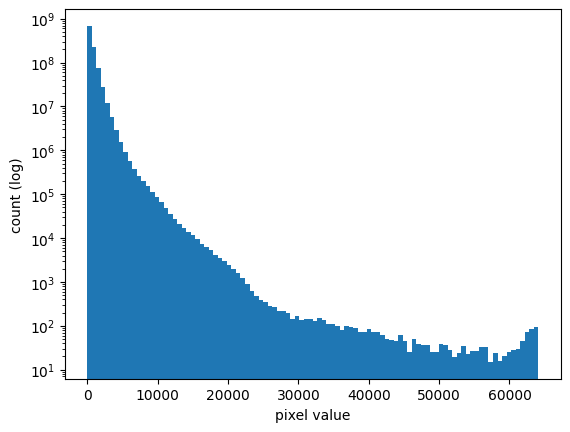

0 64068


In [56]:
# # visualize the changes as histogram 
import numpy as np
import matplotlib.pyplot as plt

# look at the actual value distribution
plt.hist(background_subtracted_rolling.ravel(), bins=100)
plt.yscale('log')
plt.xlabel('pixel value')
plt.ylabel('count (log)')
plt.show()

print(background_subtracted_rolling.min(), background_subtracted_rolling.max())

### 2. Deconvolution

#### 2.1 PSF Centering

In [13]:
psf_path = 'PSF_488nm_cnx.h5'
psf_name = 'PSF_488'

In [ ]:
# open the psf file 
with h5py.File(BASE_DIR/'data/experimental_PSF'/psf_path, "r") as f:
    psf = f[f'{psf_name}/ImageData/Image'][:]
    psf_info = f[f'{psf_name}/ImageData/Image']
    # f.visit(print) # show all keys

    # find out what axis corresponds the which scale: 
    print("shape of PSF:", psf_info.shape)
    print("number of dims:", len(psf_info.dims))

    for i, dim in enumerate(psf_info.dims):
        print("axis", i, "number of attached scales:", len(dim))

In [ ]:
stackview.imshow(psf[0,0], axes = True )

In [ ]:
# find the brightest slide 
brightest_slide = preproc.brightest_slice(psf_red)
print("The brightest slide index:", brightest_slide)

In [ ]:
# center the psf
psf_centered = preproc.center_psf(psf_red, brightest_slice)

In [ ]:
# normalize psf 
psf_normalized = preproc.normalize_psf(psf_centered)
print("normalized sum should be 1: ", psf_normalized.sum())

In [ ]:
stackview.imshow(psf_normalized[psf_normalized.shape[0]//2], colormap='gray', title="Center PSF slice")

In [ ]:
# save psf  
io.imsave(Path(BASE_DIR/'data'/'experimental_PSF'/f"{psf_name}_centered.tiff"), psf_normalized)

#### 2.2. Richardson Lucy 

In [2]:
#load centered and normalized PSF
psf_centered = io.imread('PSF_488_centered.tiff')

# load background substracted image
background_subtracted_rolling = io.imread('preprocessed_images/background_removed_img.tiff')

In [3]:
#check if noramlized [0,1]
psf_normalized = psf_centered / psf_centered.sum()
psf_normalized.sum()

np.float32(1.0)

In [17]:
# pip install redlionfish

In [4]:
image_float32 = background_subtracted_rolling.astype(np.float32)

In [5]:
# convert image so its same dtype as PSF 
image_float32.dtype

dtype('float32')

In [8]:
import RedLionfishDeconv as rl

result = rl.doRLDeconvolutionFromNpArrays(
    image_float32, psf_normalized[16:],
    niter=7, method='gpu'  # falls back to CPU if no GPU available
)

In [9]:
# save deconvolved image 
io.imsave('preprocessed_images/background_removed_and_deconvolved_img.tiff', result)

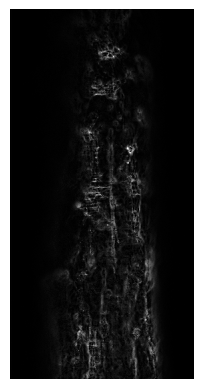

In [10]:
stackview.imshow(background_subtracted_rolling[150]) 